# PointNet Binary Classification (Clean Notebook)

This notebook trains and evaluates PointNet for binary classification on Fantastic Breaks.

- Label `0`: complete object (`model_c.ply`)
- Label `1`: broken object (`model_b_0.ply`)

**Notebook map**
1. Setup and compatibility patching
2. Runtime config (`full` vs `smoke`)
3. Data loading and quick visualization
4. Model + graph construction
5. Train/evaluate run flow
6. Manual visual inference

## 1. Setup & Imports

In [1]:
import importlib
import os
import sys
import time
from copy import deepcopy
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, accuracy_score

try:
    from IPython import get_ipython

    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import tensorflow as tf

tf1 = tf.compat.v1
tf1.disable_eager_execution()


def find_project_root(start_dir=None):
    start = Path(start_dir or os.getcwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'pointnet-master').is_dir() and (candidate / 'data' / 'classification').is_dir():
            return candidate
    raise FileNotFoundError(f'Could not locate project root from {start}')


PROJECT_ROOT = find_project_root()
POINTNET_DIR = PROJECT_ROOT / 'src' / 'pointnet-master'
sys.path.insert(0, str(POINTNET_DIR))
sys.path.insert(0, str(POINTNET_DIR / 'models'))
sys.path.insert(0, str(POINTNET_DIR / 'utils'))

# PointNet repository is TF1-based. These aliases keep TF2 runtime compatible.
tf.contrib = type(sys)('contrib')
tf.contrib.layers = type(sys)('layers')
tf.contrib.layers.xavier_initializer = tf1.initializers.glorot_uniform
tf.get_variable = tf1.get_variable
tf.variable_scope = tf1.variable_scope
tf.placeholder = tf1.placeholder
tf.train = tf1.train
tf.nn.max_pool = tf1.nn.max_pool
tf.global_variables_initializer = tf1.global_variables_initializer
tf.Session = tf1.Session
tf.ConfigProto = tf1.ConfigProto
tf.summary = tf1.summary
tf.add_to_collection = tf1.add_to_collection
tf.truncated_normal_initializer = tf1.truncated_normal_initializer
tf.to_int64 = lambda x: tf.cast(x, tf.int64)
tf.device = tf1.device
tf.cond = tf1.cond


def static_dim(tensor, axis):
    dim = tensor.get_shape()[axis]
    return dim.value if hasattr(dim, 'value') else dim


def softmax_np(logits):
    shifted = logits - np.max(logits, axis=-1, keepdims=True)
    exp_logits = np.exp(shifted)
    return exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)


import tf_util
import transform_nets

importlib.reload(tf_util)
importlib.reload(transform_nets)

from transform_nets import feature_transform_net, input_transform_net

AVAILABLE_GPUS = tf.config.list_physical_devices('GPU')

print(f'TensorFlow version: {tf.__version__}')
print(f'Detected GPUs: {AVAILABLE_GPUS}')
print(f'Project root: {PROJECT_ROOT}')

2026-03-25 11:08:57.229142: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 11:08:59.223365: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-25 11:08:59.223480: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-25 11:08:59.563016: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-25 11:09:00.250783: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.15.1
Detected GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]
Project root: /storage/student6/dev/3D-Segmentation-Restoration


## 2. Runtime Configuration

In [2]:
LABEL_NAMES = np.array(['Complete', 'Broken'])

BASE_CONFIG = {
    'data_dir': str(PROJECT_ROOT / 'data' / 'classification'),
    'log_dir': str(PROJECT_ROOT / 'src' / 'results' / 'pointnet_cls'),
    'gpu_index': 3,
    'num_point': None,
    'num_classes': 2,
    'batch_size': 16,
    'max_epoch': 200,
    'learning_rate': 0.001,
    'decay_step': 200000,
    'decay_rate': 0.7,
    'reg_weight': 0.001,
    'class_weights': [1.0, 1.25],
    'use_class_weights': True,
    'train_limit': None,
    'test_limit': None,
    'eval_limit': None,
    'seed': 42,
    'print_every': 20,
    'rotate_augment': True,
    'jitter_augment': True,
    'save_final': True,
    'inference_plot_limit': 25000,
    'classification_test_ratio': 0.20,
    'classification_split_seed': 42,
    'scale_augment': True,
    'shift_augment': True,
    'dropout_augment': True,
    'point_dropout_ratio': 0.1,
    'checkpoint_metric': 'broken_f1',
    'checkpoint_metric_mode': 'max',
}

SMOKE_CONFIG = {
    'log_dir': '/tmp/pointnet_cls_smoke',
    'num_point': 1024,
    'max_epoch': 2,
    'train_limit': 64,
    'test_limit': 32,
    'eval_limit': 32,
    'print_every': 1,
    'save_final': False,
}


def build_config(run_mode=None, **overrides):
    resolved_mode = (run_mode or os.environ.get('POINTNET_RUN_MODE', 'full')).strip().lower()
    if resolved_mode not in {'full', 'smoke'}:
        raise ValueError(f"Unsupported run mode: {resolved_mode}. Expected 'full' or 'smoke'.")

    cfg = deepcopy(BASE_CONFIG)
    if resolved_mode == 'smoke':
        cfg.update(SMOKE_CONFIG)
    cfg.update(overrides)
    cfg['run_mode'] = resolved_mode

    cfg['device_name'] = (
        f"/gpu:{cfg['gpu_index']}"
        if cfg['gpu_index'] < len(AVAILABLE_GPUS)
        else '/cpu:0'
    )

    Path(cfg['log_dir']).mkdir(parents=True, exist_ok=True)
    return cfg


def print_config(cfg):
    keys = [
        'run_mode', 'device_name', 'data_dir', 'log_dir', 'num_point', 'batch_size',
        'max_epoch', 'learning_rate', 'train_limit', 'test_limit', 'eval_limit',
        'rotate_augment', 'jitter_augment', 'seed',
    ]
    print('PointNet configuration')
    for key in keys:
        print(f"  {key:16s}: {cfg[key]}")


CONFIG = build_config()
print_config(CONFIG)

PointNet configuration
  run_mode        : full
  device_name     : /gpu:3
  data_dir        : /storage/student6/dev/3D-Segmentation-Restoration/data/classification
  log_dir         : /storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls
  num_point       : None
  batch_size      : 16
  max_epoch       : 200
  learning_rate   : 0.001
  train_limit     : None
  test_limit      : None
  eval_limit      : None
  rotate_augment  : True
  jitter_augment  : True
  seed            : 42


## 3. Data Loading

In [3]:
def load_h5(path):
    with h5py.File(path, 'r') as f:
        data = f['data'][:]
        labels = f['label'][:].flatten().astype(np.int32)
    return data, labels


def apply_sample_limit(data, labels, limit, seed):
    if limit is None or int(limit) >= len(data):
        idx = np.arange(len(data), dtype=np.int32)
        return data, labels, idx

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(data), size=int(limit), replace=False)
    idx.sort()
    return data[idx], labels[idx], idx.astype(np.int32)


def load_object_ids(object_ids_path):
    object_ids = [line.strip() for line in Path(object_ids_path).read_text().splitlines() if line.strip()]
    if not object_ids:
        raise ValueError(f'No object IDs found in {object_ids_path}')
    return object_ids


def reconstruct_classification_split(object_ids, test_ratio, seed):
    labels = np.array([0 if object_id.endswith('_c') else 1 for object_id in object_ids], dtype=np.int32)
    rng = np.random.default_rng(seed)
    indices = np.arange(len(labels))
    rng.shuffle(indices)

    complete_idx = indices[labels[indices] == 0]
    broken_idx = indices[labels[indices] == 1]

    n_test_complete = int(len(complete_idx) * test_ratio)
    n_test_broken = int(len(broken_idx) * test_ratio)

    test_idx = np.concatenate([complete_idx[:n_test_complete], broken_idx[:n_test_broken]])
    train_idx = np.concatenate([complete_idx[n_test_complete:], broken_idx[n_test_broken:]])

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return train_idx, test_idx, labels


def attach_split_object_ids(cfg, dataset, train_full_label, test_full_label):
    object_ids_path = Path(cfg['data_dir']) / 'object_ids.txt'
    if not object_ids_path.exists():
        return dataset

    object_ids = np.asarray(load_object_ids(object_ids_path), dtype=object)
    expected_total = len(train_full_label) + len(test_full_label)
    if len(object_ids) != expected_total:
        print(
            f'Skipping object ID attachment because {object_ids_path} has {len(object_ids)} IDs '
            f'but dataset expects {expected_total}.'
        )
        return dataset

    train_idx, test_idx, labels = reconstruct_classification_split(
        object_ids,
        test_ratio=cfg['classification_test_ratio'],
        seed=cfg['classification_split_seed'],
    )

    train_full_indices = np.asarray(dataset['train_full_indices'], dtype=np.int32)
    test_full_indices = np.asarray(dataset['test_full_indices'], dtype=np.int32)
    expected_train_labels = labels[train_idx][train_full_indices]
    expected_test_labels = labels[test_idx][test_full_indices]

    if not np.array_equal(expected_train_labels, dataset['train_label']):
        print('Skipping train object ID attachment because reconstructed labels do not match the loaded train split.')
        return dataset
    if not np.array_equal(expected_test_labels, dataset['test_label']):
        print('Skipping test object ID attachment because reconstructed labels do not match the loaded test split.')
        return dataset

    dataset = dict(dataset)
    dataset['object_ids'] = object_ids
    dataset['train_ids'] = np.asarray(object_ids[train_idx][train_full_indices], dtype=object)
    dataset['test_ids'] = np.asarray(object_ids[test_idx][test_full_indices], dtype=object)
    return dataset


def summarize_split(name, labels):
    labels = np.asarray(labels).reshape(-1)
    complete = int(np.sum(labels == 0))
    broken = int(np.sum(labels == 1))
    print(f"{name:<6s} -> n={len(labels):4d} | complete={complete:4d} | broken={broken:4d}")


def load_datasets(cfg):
    train_path = Path(cfg['data_dir']) / 'train_data.h5'
    test_path = Path(cfg['data_dir']) / 'test_data.h5'

    if not train_path.exists() or not test_path.exists():
        raise FileNotFoundError(
            f"Missing classification H5 files in {cfg['data_dir']}. "
            'Run scripts/prepare_classification_data.py first.'
        )

    train_full_data, train_full_label = load_h5(train_path)
    test_full_data, test_full_label = load_h5(test_path)

    cfg = dict(cfg)
    if cfg['num_point'] is None:
        cfg['num_point'] = int(train_full_data.shape[1])

    if cfg['num_point'] > train_full_data.shape[1]:
        raise ValueError(
            f"num_point={cfg['num_point']} exceeds available points per cloud ({train_full_data.shape[1]})."
        )

    train_data, train_label, train_full_indices = apply_sample_limit(
        train_full_data,
        train_full_label,
        cfg['train_limit'],
        cfg['seed'],
    )
    test_data, test_label, test_full_indices = apply_sample_limit(
        test_full_data,
        test_full_label,
        cfg['test_limit'],
        cfg['seed'] + 1,
    )

    dataset = {
        'train_data': train_data,
        'train_label': train_label,
        'test_data': test_data,
        'test_label': test_label,
        'train_full_indices': train_full_indices,
        'test_full_indices': test_full_indices,
        'train_total_count': int(len(train_full_label)),
        'test_total_count': int(len(test_full_label)),
    }
    dataset = attach_split_object_ids(cfg, dataset, train_full_label, test_full_label)

    print(f"Using num_point={cfg['num_point']} from data shape {train_full_data.shape[1]}")
    summarize_split('Train', train_label)
    summarize_split('Test', test_label)
    if 'test_ids' in dataset:
        print(f"Attached {len(dataset['test_ids'])} test object IDs from object_ids.txt")
    return cfg, dataset


CONFIG, DATASET = load_datasets(CONFIG)


Using num_point=8192 from data shape 8192
Train  -> n= 240 | complete= 120 | broken= 120
Test   -> n=  60 | complete=  30 | broken=  30
Attached 60 test object IDs from object_ids.txt


## 4. Quick Visual Check

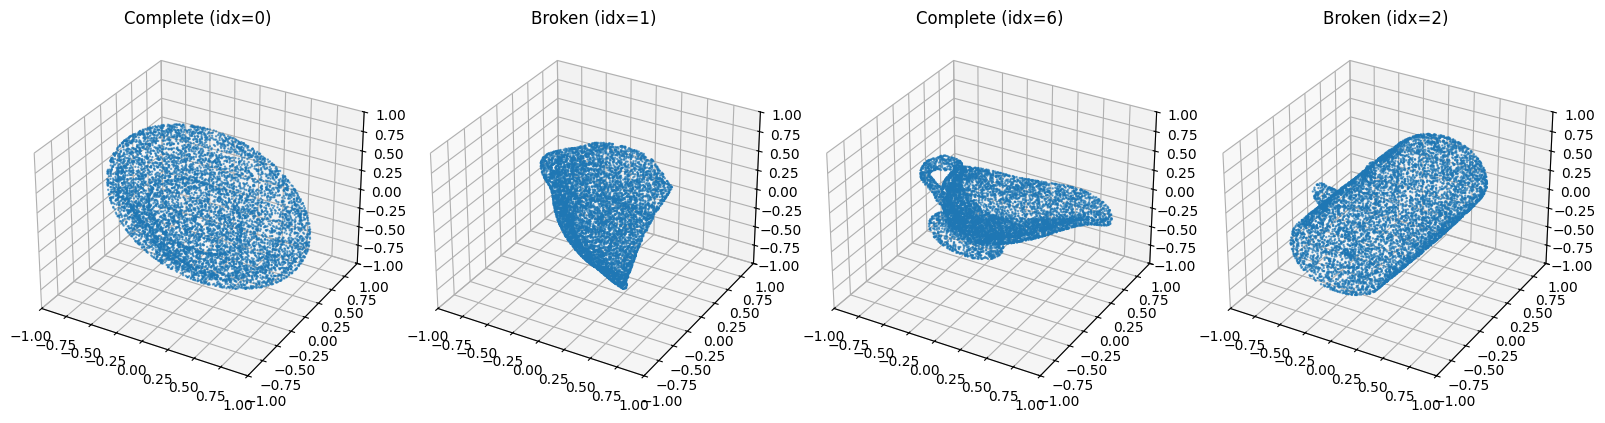

In [4]:
def plot_sample_point_clouds(data, labels, label_names=None, max_examples=4):
    label_names = label_names if label_names is not None else np.array(['Class 0', 'Class 1'])
    max_examples = max(2, int(max_examples))
    fig, axes = plt.subplots(1, max_examples, figsize=(4 * max_examples, 4), subplot_kw={'projection': '3d'})

    for plot_idx, ax in enumerate(axes):
        target_label = plot_idx % 2
        label_positions = np.where(labels == target_label)[0]
        if len(label_positions) == 0:
            ax.set_title(f'No samples for label {target_label}')
            ax.axis('off')
            continue

        sample_idx = int(label_positions[min(plot_idx // 2, len(label_positions) - 1)])
        points = data[sample_idx]
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=0.5, alpha=0.65)
        ax.set_title(f"{label_names[target_label]} (idx={sample_idx})")
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_zlim(-1, 1)

    plt.tight_layout()
    plt.show()


plot_sample_point_clouds(DATASET['train_data'], DATASET['train_label'], LABEL_NAMES, max_examples=4)

## 5. Data Augmentation Utilities

In [5]:
def shuffle_data(data, labels, rng=None):
    rng = rng or np.random.default_rng()
    idx = np.arange(len(labels))
    rng.shuffle(idx)
    return data[idx], labels[idx]


def rotate_point_cloud(batch_data, rng=None):
    rng = rng or np.random.default_rng()
    rotated = np.zeros(batch_data.shape, dtype=np.float32)
    for k in range(batch_data.shape[0]):
        angle = float(rng.uniform(0.0, 2.0 * np.pi))
        c, s = np.cos(angle), np.sin(angle)
        rotation = np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]], dtype=np.float32)
        rotated[k] = batch_data[k] @ rotation
    return rotated


def jitter_point_cloud(batch_data, sigma=0.01, clip=0.05, rng=None):
    rng = rng or np.random.default_rng()
    noise = np.clip(sigma * rng.standard_normal(batch_data.shape), -clip, clip)
    return batch_data + noise.astype(np.float32)

def random_scale_point_cloud(batch_data, scale_low=0.9, scale_high=1.1, rng=None):
    rng = rng or np.random.default_rng()
    scaled = np.empty_like(batch_data, dtype=np.float32)
    for k in range(batch_data.shape[0]):
        s = float(rng.uniform(scale_low, scale_high))
        scaled[k] = batch_data[k] * s
    return scaled


def shift_point_cloud(batch_data, shift_range=0.1, rng=None):
    rng = rng or np.random.default_rng()
    shifts = rng.uniform(-shift_range, shift_range, size=(batch_data.shape[0], 1, 3))
    return batch_data + shifts.astype(np.float32)


def random_point_dropout(batch_data, max_dropout_ratio=0.1, rng=None):
    rng = rng or np.random.default_rng()
    dropped = batch_data.copy()
    for b in range(batch_data.shape[0]):
        dropout_ratio = float(rng.uniform(0.0, max_dropout_ratio))
        drop_idx = rng.random(batch_data.shape[1]) < dropout_ratio
        if np.any(drop_idx):
            dropped[b, drop_idx, :] = dropped[b, 0, :]
    return dropped

print('Augmentation helpers are ready.')

Augmentation helpers are ready.


## 6. PointNet Model Definition

In [6]:
def get_model(point_cloud, is_training, cfg, bn_decay=None):
    num_point = static_dim(point_cloud, 1)
    end_points = {}

    with tf1.variable_scope('transform_net1'):
        transform = input_transform_net(point_cloud, is_training, bn_decay, K=3)
    point_cloud_transformed = tf.matmul(point_cloud, transform)
    input_image = tf.expand_dims(point_cloud_transformed, -1)

    net = tf_util.conv2d(
        input_image,
        64,
        [1, 3],
        padding='VALID',
        stride=[1, 1],
        bn=True,
        is_training=is_training,
        scope='conv1',
        bn_decay=bn_decay,
    )
    net = tf_util.conv2d(
        net,
        64,
        [1, 1],
        padding='VALID',
        stride=[1, 1],
        bn=True,
        is_training=is_training,
        scope='conv2',
        bn_decay=bn_decay,
    )

    with tf1.variable_scope('transform_net2'):
        transform = feature_transform_net(net, is_training, bn_decay, K=64)
    end_points['transform'] = transform
    net_transformed = tf.matmul(tf.squeeze(net, axis=[2]), transform)
    net_transformed = tf.expand_dims(net_transformed, [2])

    net = tf_util.conv2d(
        net_transformed,
        64,
        [1, 1],
        padding='VALID',
        stride=[1, 1],
        bn=True,
        is_training=is_training,
        scope='conv3',
        bn_decay=bn_decay,
    )
    net = tf_util.conv2d(
        net,
        128,
        [1, 1],
        padding='VALID',
        stride=[1, 1],
        bn=True,
        is_training=is_training,
        scope='conv4',
        bn_decay=bn_decay,
    )
    net = tf_util.conv2d(
        net,
        1024,
        [1, 1],
        padding='VALID',
        stride=[1, 1],
        bn=True,
        is_training=is_training,
        scope='conv5',
        bn_decay=bn_decay,
    )

    net = tf_util.max_pool2d(net, [num_point, 1], padding='VALID', scope='maxpool')
    net = tf.reshape(net, [-1, 1024])
    net.set_shape([None, 1024])

    net = tf_util.fully_connected(net, 512, bn=True, is_training=is_training, scope='fc1', bn_decay=bn_decay)
    net = tf_util.dropout(net, keep_prob=0.7, is_training=is_training, scope='dp1')
    net = tf_util.fully_connected(net, 256, bn=True, is_training=is_training, scope='fc2', bn_decay=bn_decay)
    net = tf_util.dropout(net, keep_prob=0.7, is_training=is_training, scope='dp2')
    logits = tf_util.fully_connected(net, cfg['num_classes'], activation_fn=None, scope='fc3')
    return logits, end_points


def get_loss(pred, label, end_points, reg_weight=0.001, class_weights=None):
    if class_weights is None:
        ce_loss = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(logits=pred, labels=label)
        )
    else:
        class_weights = tf.constant(class_weights, dtype=tf.float32)
        sample_weights = tf.gather(class_weights, label)
        per_sample_loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
            logits=pred,
            labels=label,
        )
        ce_loss = tf.reduce_mean(per_sample_loss * sample_weights)

    transform = end_points['transform']
    k = static_dim(transform, 1)
    mat_diff = tf.matmul(transform, tf.transpose(transform, perm=[0, 2, 1]))
    mat_diff -= tf.constant(np.eye(k), dtype=tf.float32)
    mat_loss = tf.nn.l2_loss(mat_diff)

    return ce_loss + mat_loss * reg_weight


print('Model and loss definitions loaded.')

Model and loss definitions loaded.


## 7. Graph Construction

In [7]:
def get_learning_rate(global_step, cfg):
    lr = tf1.train.exponential_decay(
        cfg['learning_rate'],
        global_step * cfg['batch_size'],
        cfg['decay_step'],
        cfg['decay_rate'],
        staircase=True,
    )
    return tf.maximum(lr, 1e-5)


def get_bn_decay(global_step, cfg):
    bn_mom = tf1.train.exponential_decay(
        0.5,
        global_step * cfg['batch_size'],
        float(cfg['decay_step']),
        0.5,
        staircase=True,
    )
    return tf.minimum(0.99, 1 - bn_mom)


def build_graph(cfg):
    graph = tf.Graph()
    with graph.as_default():
        with tf1.device(cfg['device_name']):
            pointclouds_pl = tf1.placeholder(
                tf.float32,
                (None, cfg['num_point'], 3),
                name='pointclouds',
            )
            labels_pl = tf1.placeholder(tf.int32, (None,), name='labels')
            is_training_pl = tf1.placeholder(tf.bool, (), name='is_training')

            global_step = tf.Variable(0, name='global_step')
            bn_decay = get_bn_decay(global_step, cfg)
            pred, end_points = get_model(pointclouds_pl, is_training_pl, cfg, bn_decay=bn_decay)
            loss = get_loss(
                pred,
                labels_pl,
                end_points,
                reg_weight=cfg['reg_weight'],
                class_weights=cfg['class_weights'] if cfg.get('use_class_weights') else None,
            )

            correct = tf.equal(tf.argmax(pred, 1), tf.cast(labels_pl, tf.int64))
            accuracy = tf.reduce_mean(tf.cast(correct, tf.float32))

            learning_rate = get_learning_rate(global_step, cfg)
            optimizer = tf1.train.AdamOptimizer(learning_rate)
            train_op = optimizer.minimize(loss, global_step=global_step)
            saver = tf1.train.Saver()

    return {
        'graph': graph,
        'pointclouds_pl': pointclouds_pl,
        'labels_pl': labels_pl,
        'is_training_pl': is_training_pl,
        'pred': pred,
        'loss': loss,
        'accuracy': accuracy,
        'train_op': train_op,
        'saver': saver,
    }


def create_session_config():
    cfg = tf1.ConfigProto()
    cfg.gpu_options.allow_growth = True
    cfg.allow_soft_placement = True
    return cfg


print('Graph builder is ready.')


Graph builder is ready.


## 8. Training and Evaluation Helpers

### 8.1 Batch and Epoch Routines

In [8]:
def trim_to_full_batches(data, labels, batch_size):
    n_batches = len(data) // batch_size
    if n_batches == 0:
        raise ValueError(
            f'Need at least one full batch. got {len(data)} samples and batch_size={batch_size}.'
        )
    usable = n_batches * batch_size
    if usable < len(data):
        print(f'Trimming {len(data) - usable} samples to keep full batches.')
    return data[:usable], labels[:usable], n_batches

def iter_batches(data, labels, batch_size):
    n = len(data)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        yield data[start:end], labels[start:end]


def compute_eval_metrics(labels, preds):
    labels = np.asarray(labels, dtype=np.int32)
    preds = np.asarray(preds, dtype=np.int32)

    acc = float(np.mean(labels == preds))

    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    complete_precision = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    complete_recall    = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    complete_f1 = (
        2 * complete_precision * complete_recall / (complete_precision + complete_recall)
        if (complete_precision + complete_recall) > 0 else 0.0
    )

    broken_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    broken_recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    broken_f1 = (
        2 * broken_precision * broken_recall / (broken_precision + broken_recall)
        if (broken_precision + broken_recall) > 0 else 0.0
    )

    macro_f1 = 0.5 * (complete_f1 + broken_f1)

    return {
        'accuracy': acc,
        'confusion_matrix': cm,
        'complete_precision': complete_precision,
        'complete_recall': complete_recall,
        'complete_f1': complete_f1,
        'broken_precision': broken_precision,
        'broken_recall': broken_recall,
        'broken_f1': broken_f1,
        'macro_f1': macro_f1,
    }


def run_train_epoch(sess, handles, cfg, train_data, train_label, epoch_seed):
    rng = np.random.default_rng(epoch_seed)
    shuffled_data, shuffled_label = shuffle_data(train_data, train_label, rng=rng)
    shuffled_data, shuffled_label, n_batches = trim_to_full_batches(
        shuffled_data,
        shuffled_label,
        cfg['batch_size'],
    )

    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    for batch_idx in range(n_batches):
        start = batch_idx * cfg['batch_size']
        end = (batch_idx + 1) * cfg['batch_size']
        batch_data = shuffled_data[start:end, : cfg['num_point'], :]
        batch_label = shuffled_label[start:end]

        if cfg['rotate_augment']:
            batch_data = rotate_point_cloud(batch_data, rng=rng)
        if cfg['jitter_augment']:
            batch_data = jitter_point_cloud(batch_data, rng=rng)
        if cfg.get('scale_augment', False):
            batch_data = random_scale_point_cloud(batch_data, rng=rng)
        if cfg.get('shift_augment', False):
            batch_data = shift_point_cloud(batch_data, rng=rng)
        if cfg.get('dropout_augment', False):
            batch_data = random_point_dropout(
                batch_data,
                max_dropout_ratio=cfg.get('point_dropout_ratio', 0.1),
                rng=rng,
            )

        _, loss_val, pred_val = sess.run(
            [handles['train_op'], handles['loss'], handles['pred']],
            feed_dict={
                handles['pointclouds_pl']: batch_data,
                handles['labels_pl']: batch_label,
                handles['is_training_pl']: True,
            },
        )

        total_loss += float(loss_val)
        total_correct += int(np.sum(np.argmax(pred_val, axis=1) == batch_label))
        total_seen += len(batch_label)

    return {
        'loss': total_loss / n_batches,
        'acc': total_correct / total_seen,
        'num_batches': n_batches,
    }


def run_eval_epoch(sess, handles, cfg, eval_data, eval_label):
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    num_batches = 0
    all_labels = []
    all_preds = []

    for batch_data, batch_label in iter_batches(
        eval_data[:, : cfg['num_point'], :],
        eval_label,
        cfg['batch_size'],
    ):
        logits, loss_val = sess.run(
            [handles['pred'], handles['loss']],
            feed_dict={
                handles['pointclouds_pl']: batch_data,
                handles['labels_pl']: batch_label,
                handles['is_training_pl']: False,
            },
        )

        preds = np.argmax(logits, axis=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(batch_label.tolist())
        total_loss += float(loss_val) * len(batch_label)
        total_correct += int(np.sum(preds == batch_label))
        total_seen += len(batch_label)
        num_batches += 1

    if total_seen == 0:
        raise ValueError('Evaluation split is empty.')

    all_labels = np.asarray(all_labels, dtype=np.int32)
    all_preds = np.asarray(all_preds, dtype=np.int32)
    metrics = compute_eval_metrics(all_labels, all_preds)

    return {
        'loss': total_loss / total_seen,
        'acc': total_correct / total_seen,
        'labels': all_labels,
        'preds': all_preds,
        'metrics': metrics,
        'num_batches': num_batches,
    }


### 8.2 Training and Checkpoint Evaluation

In [9]:
def get_checkpoint_score(eval_out, cfg):
    metric_name = cfg.get('checkpoint_metric', 'accuracy')

    metrics = eval_out.get('metrics', None)
    if metrics is None:
        metrics = compute_eval_metrics(eval_out['labels'], eval_out['preds'])

    if metric_name == 'accuracy':
        return metrics['accuracy']
    elif metric_name == 'macro_f1':
        return metrics['macro_f1']
    elif metric_name == 'broken_recall':
        return metrics['broken_recall']
    elif metric_name == 'broken_f1':
        return metrics['broken_f1']
    else:
        raise ValueError(f'Unsupported checkpoint_metric: {metric_name}')


def is_better_checkpoint_score(current_score, best_score, cfg):
    if best_score is None:
        return True

    mode = cfg.get('checkpoint_metric_mode', 'max').strip().lower()
    if mode == 'max':
        return current_score >= best_score
    if mode == 'min':
        return current_score <= best_score
    raise ValueError(f'Unsupported checkpoint_metric_mode: {mode}')


def train_model(cfg, dataset, handles):
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'test_macro_f1': [],
        'test_broken_recall': [],
        'test_broken_f1': [],
        'best_accuracy': 0.0,
        'best_score': None,
        'best_epoch': None,
        'best_checkpoint': None,
        'final_checkpoint': None,
    }

    train_data = dataset['train_data'][:, : cfg['num_point'], :]
    train_label = dataset['train_label']
    test_data = dataset['test_data'][:, : cfg['num_point'], :]
    test_label = dataset['test_label']

    best_checkpoint = str(Path(cfg['log_dir']) / 'best_model.ckpt')
    final_checkpoint = str(Path(cfg['log_dir']) / 'final_model.ckpt')

    session_config = create_session_config()
    with tf1.Session(graph=handles['graph'], config=session_config) as sess:
        sess.run(tf1.global_variables_initializer())
        best_acc = 0.0

        for epoch in range(cfg['max_epoch']):
            train_metrics = run_train_epoch(
                sess,
                handles,
                cfg,
                train_data,
                train_label,
                epoch_seed=cfg['seed'] + epoch,
            )
            test_metrics = run_eval_epoch(sess, handles, cfg, test_data, test_label)
            eval_metrics = test_metrics['metrics']

            history['train_loss'].append(train_metrics['loss'])
            history['train_acc'].append(train_metrics['acc'])
            history['test_loss'].append(test_metrics['loss'])
            history['test_acc'].append(test_metrics['acc'])
            history['test_macro_f1'].append(eval_metrics['macro_f1'])
            history['test_broken_recall'].append(eval_metrics['broken_recall'])
            history['test_broken_f1'].append(eval_metrics['broken_f1'])

            current_score = float(get_checkpoint_score(test_metrics, cfg))
            if is_better_checkpoint_score(current_score, history['best_score'], cfg):
                history['best_score'] = current_score
                history['best_epoch'] = epoch
                best_acc = float(test_metrics['acc'])
                handles['saver'].save(sess, best_checkpoint)

            if (epoch % cfg['print_every'] == 0) or (epoch == cfg['max_epoch'] - 1):
                print(
                    f"Epoch {epoch:3d} | "
                    f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['acc']:.4f} | "
                    f"test_loss={test_metrics['loss']:.4f} test_acc={test_metrics['acc']:.4f}"
                )

        if cfg['save_final']:
            handles['saver'].save(sess, final_checkpoint)

    history['best_accuracy'] = float(best_acc)
    history['best_checkpoint'] = best_checkpoint
    history['final_checkpoint'] = final_checkpoint if cfg['save_final'] else None

    print(f"Best validation accuracy: {history['best_accuracy']:.4f}")
    print(f"Best checkpoint: {history['best_checkpoint']}")
    return history


def evaluate_checkpoint(cfg, dataset, handles, checkpoint_path, limit=None):
    if checkpoint_path is None:
        raise ValueError('checkpoint_path is required for evaluation.')

    checkpoint_path = str(checkpoint_path)
    if not Path(checkpoint_path + '.index').exists():
        raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

    eval_data = dataset['test_data'][:, : cfg['num_point'], :]
    eval_label = dataset['test_label']
    eval_ids = np.asarray(
        dataset.get('test_ids', [f'test_sample_{i}' for i in range(len(eval_label))]),
        dtype=object,
    )

    if limit is not None:
        eval_data, eval_label, eval_idx = apply_sample_limit(eval_data, eval_label, limit, cfg['seed'] + 99)
        eval_ids = eval_ids[eval_idx]

    all_preds = []
    all_probs = []
    all_labels = []
    total_loss = 0.0
    total_seen = 0

    session_config = create_session_config()
    with tf1.Session(graph=handles['graph'], config=session_config) as sess:
        handles['saver'].restore(sess, checkpoint_path)

        for batch_data, batch_label in iter_batches(eval_data, eval_label, cfg['batch_size']):
            logits, loss_val = sess.run(
                [handles['pred'], handles['loss']],
                feed_dict={
                    handles['pointclouds_pl']: batch_data,
                    handles['labels_pl']: batch_label,
                    handles['is_training_pl']: False,
                },
            )

            probs = softmax_np(logits)
            preds = np.argmax(logits, axis=1)

            all_preds.extend(preds.tolist())
            all_probs.extend(probs[:, 1].tolist())
            all_labels.extend(batch_label.tolist())
            total_loss += float(loss_val) * len(batch_label)
            total_seen += len(batch_label)

    if total_seen == 0:
        raise ValueError('Evaluation split is empty.')

    all_preds = np.asarray(all_preds, dtype=np.int32)
    all_probs = np.asarray(all_probs, dtype=np.float32)
    all_labels = np.asarray(all_labels, dtype=np.int32)
    metrics = compute_eval_metrics(all_labels, all_preds)

    report = classification_report(
        all_labels,
        all_preds,
        labels=[0, 1],
        target_names=LABEL_NAMES.tolist(),
        digits=4,
        zero_division=0,
    )
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    acc = accuracy_score(all_labels, all_preds)

    return {
        'loss': total_loss / total_seen,
        'accuracy': float(acc),
        'labels': all_labels,
        'preds': all_preds,
        'probs_broken': all_probs,
        'confusion_matrix': cm,
        'report': report,
        'metrics': metrics,
        'object_ids': eval_ids,
    }


def summarize_errors(eval_result, object_ids=None, top_k=10):
    labels = eval_result['labels']
    preds = eval_result['preds']
    probs_broken = eval_result['probs_broken']

    wrong_idx = np.where(labels != preds)[0]
    if len(wrong_idx) == 0:
        print('No errors.')
        return

    print(f'Total errors: {len(wrong_idx)}')

    rows = []
    for i in wrong_idx:
        rows.append({
            'idx': int(i),
            'object_id': object_ids[i] if object_ids is not None else f'sample_{i}',
            'true_label': LABEL_NAMES[labels[i]],
            'pred_label': LABEL_NAMES[preds[i]],
            'p_broken': float(probs_broken[i]),
            'confidence': float(max(probs_broken[i], 1.0 - probs_broken[i])),
        })

    rows = sorted(rows, key=lambda x: x['confidence'], reverse=True)

    print('\nMost confident mistakes:')
    for row in rows[:top_k]:
        print(
            f"{row['idx']:3d} | {row['object_id']} | "
            f"true={row['true_label']} pred={row['pred_label']} | "
            f"p_broken={row['p_broken']:.4f} | conf={row['confidence']:.4f}"
        )


### 8.3 Plot Helpers

In [10]:
def plot_training_curves(history):
    if history is None or not history.get('train_loss'):
        print('No training history available to plot.')
        return

    has_extra_metrics = (
        'test_macro_f1' in history and
        'test_broken_recall' in history and
        'test_broken_f1' in history
    )

    if has_extra_metrics:
        fig, axes = plt.subplots(1, 3, figsize=(19, 5))
        ax1, ax2, ax3 = axes
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax1, ax2 = axes

    epochs = np.arange(1, len(history['train_loss']) + 1)

    # ---- Loss ----
    ax1.plot(epochs, history['train_loss'], label='Train loss')
    ax1.plot(epochs, history['test_loss'], label='Test loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss curves')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # ---- Accuracy ----
    ax2.plot(epochs, history['train_acc'], label='Train acc')
    ax2.plot(epochs, history['test_acc'], label='Test acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy curves')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # ---- Extra metrics if available ----
    if has_extra_metrics:
        ax3.plot(epochs, history['test_macro_f1'], label='Test macro F1')
        ax3.plot(epochs, history['test_broken_recall'], label='Test broken recall')
        ax3.plot(epochs, history['test_broken_f1'], label='Test broken F1')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Score')
        ax3.set_title('Broken-class and macro metrics')
        ax3.grid(True, alpha=0.3)
        ax3.legend()

    # ---- Mark best epoch if available ----
    best_epoch = history.get('best_epoch', None)
    if best_epoch is not None:
        best_epoch_plot = best_epoch + 1  # 0-based -> 1-based for plotting
        ax1.axvline(best_epoch_plot, linestyle='--', alpha=0.5, label='Best epoch')
        ax2.axvline(best_epoch_plot, linestyle='--', alpha=0.5)
        if has_extra_metrics:
            ax3.axvline(best_epoch_plot, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


def plot_confusion_and_roc(eval_result, output_dir=None):
    labels = np.asarray(eval_result['labels'], dtype=np.int32)
    preds = np.asarray(eval_result['preds'], dtype=np.int32)
    probs = np.asarray(eval_result['probs_broken'], dtype=np.float32)

    metrics = compute_eval_metrics(labels, preds)
    cm = eval_result.get('confusion_matrix', metrics['confusion_matrix'])
    output_dir = Path(output_dir or '/storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls')
    output_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = {}

    # ---- Confusion matrix ----
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    image = ax_cm.imshow(cm, cmap=plt.cm.Blues)
    ax_cm.set_xticks([0, 1])
    ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(list(LABEL_NAMES))
    ax_cm.set_yticklabels(list(LABEL_NAMES))
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('True')
    ax_cm.set_title('Confusion matrix')

    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            value = cm[row, col]
            color = 'white' if value > cm.max() / 2.0 else 'black'
            ax_cm.text(col, row, str(value), ha='center', va='center', color=color)

    fig_cm.colorbar(image, ax=ax_cm)
    fig_cm.tight_layout()
    cm_path = output_dir / 'confusion_matrix.png'
    fig_cm.savefig(cm_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig_cm)
    saved_paths['confusion_matrix'] = cm_path
    print(f'Saved confusion matrix to {cm_path}')

    # ---- ROC curve ----
    fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
    try:
        auc = roc_auc_score(labels, probs)
        fpr, tpr, _ = roc_curve(labels, probs)
        ax_roc.plot(fpr, tpr, label=f'PointNet (AUC={auc:.3f})')
        ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title('ROC curve')
        ax_roc.grid(True, alpha=0.3)
        ax_roc.legend()
    except Exception as exc:
        ax_roc.text(0.05, 0.5, f'ROC unavailable: {exc}', fontsize=10)
        ax_roc.set_axis_off()

    fig_roc.tight_layout()
    roc_path = output_dir / 'roc_curve.png'
    fig_roc.savefig(roc_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig_roc)
    saved_paths['roc_curve'] = roc_path
    print(f'Saved ROC curve to {roc_path}')

    # ---- Precision-Recall curve for Broken class ----
    fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
    try:
        precision, recall, _ = precision_recall_curve(labels, probs)
        ap = average_precision_score(labels, probs)
        ax_pr.plot(recall, precision, label=f'PointNet (AP={ap:.3f})')
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precision')
        ax_pr.set_title('Precision-Recall curve (Broken)')
        ax_pr.grid(True, alpha=0.3)
        ax_pr.legend()
    except Exception as exc:
        ax_pr.text(0.05, 0.5, f'PR unavailable: {exc}', fontsize=10)
        ax_pr.set_axis_off()

    fig_pr.tight_layout()
    pr_path = output_dir / 'precision_recall_curve_broken.png'
    fig_pr.savefig(pr_path, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig_pr)
    saved_paths['precision_recall_curve_broken'] = pr_path
    print(f'Saved Precision-Recall curve to {pr_path}')

    # ---- Print summary metrics ----
    print('Evaluation summary:')
    print(f"  Accuracy        : {metrics['accuracy']:.4f}")
    print(f"  Macro F1        : {metrics['macro_f1']:.4f}")
    print(f"  Broken Precision: {metrics['broken_precision']:.4f}")
    print(f"  Broken Recall   : {metrics['broken_recall']:.4f}")
    print(f"  Broken F1       : {metrics['broken_f1']:.4f}")
    print(f"  Complete Recall : {metrics['complete_recall']:.4f}")
    return saved_paths


## 9. Main Run Flow

2026-03-25 11:09:26.220628: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18522 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:18:00.0, compute capability: 8.6
2026-03-25 11:09:26.221381: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22278 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2026-03-25 11:09:26.222529: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22278 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6
2026-03-25 11:09:26.222973: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22278 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


2026-03-25 11:09:28.540810: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18522 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:18:00.0, compute capability: 8.6
2026-03-25 11:09:28.540999: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22278 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2026-03-25 11:09:28.541161: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22278 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6
2026-03-25 11:09:28.541320: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22278 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090

Epoch   0 | train_loss=1.8160 train_acc=0.5708 | test_loss=9.2091 test_acc=0.6000
Epoch  20 | train_loss=0.7117 train_acc=0.6875 | test_loss=0.5597 test_acc=0.7500
Epoch  40 | train_loss=0.6560 train_acc=0.7333 | test_loss=0.6109 test_acc=0.6500
Epoch  60 | train_loss=0.6493 train_acc=0.7583 | test_loss=1.0185 test_acc=0.6167
Epoch  80 | train_loss=0.5266 train_acc=0.7542 | test_loss=0.5393 test_acc=0.7333
Epoch 100 | train_loss=0.5856 train_acc=0.7208 | test_loss=0.8312 test_acc=0.7500
Epoch 120 | train_loss=0.5432 train_acc=0.7958 | test_loss=0.5614 test_acc=0.7167
Epoch 140 | train_loss=0.5937 train_acc=0.7375 | test_loss=0.6094 test_acc=0.7167
Epoch 160 | train_loss=0.4945 train_acc=0.7708 | test_loss=0.5552 test_acc=0.7333
Epoch 180 | train_loss=0.4162 train_acc=0.8292 | test_loss=0.6059 test_acc=0.7667
Epoch 199 | train_loss=0.3915 train_acc=0.8292 | test_loss=0.4673 test_acc=0.7667
Best validation accuracy: 0.8500
Best checkpoint: /storage/student6/dev/3D-Segmentation-Restoratio

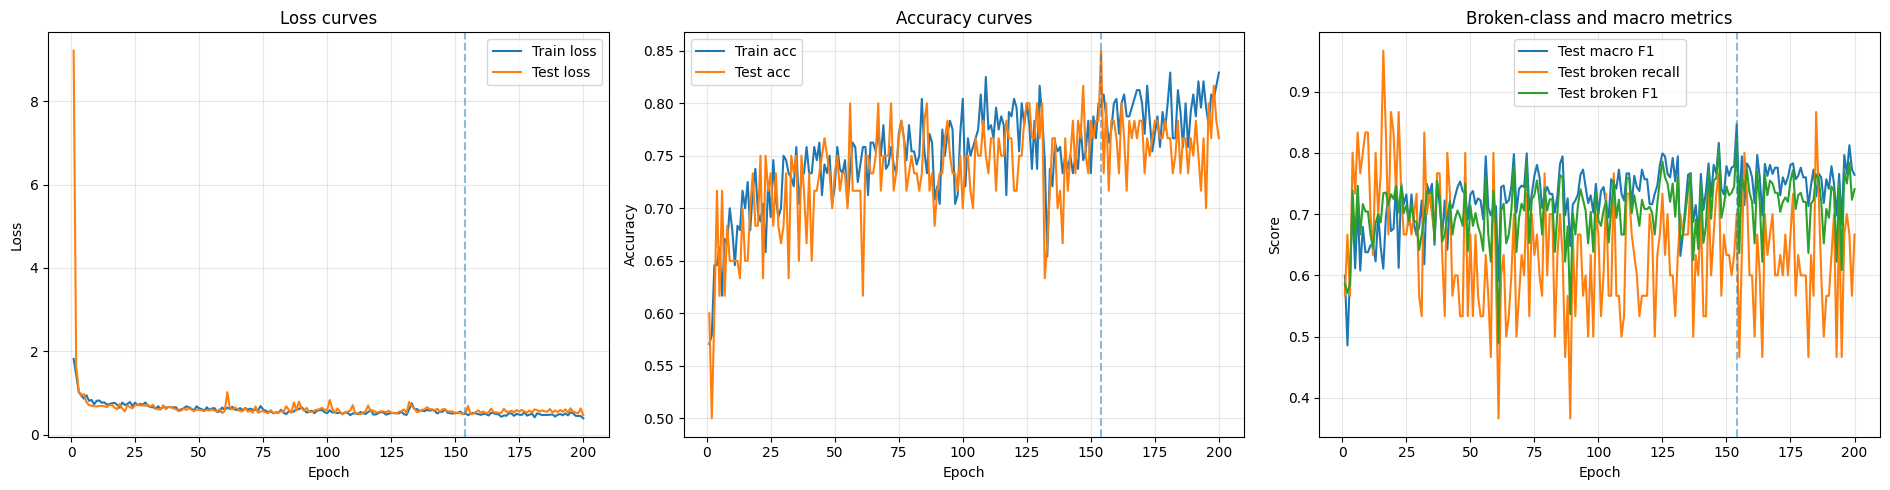

INFO:tensorflow:Restoring parameters from /storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls/best_model.ckpt


2026-03-25 11:21:19.042011: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18522 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:18:00.0, compute capability: 8.6
2026-03-25 11:21:19.042210: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22278 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2026-03-25 11:21:19.042399: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22278 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6
2026-03-25 11:21:19.042579: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22278 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090

              precision    recall  f1-score   support

    Complete     0.7692    1.0000    0.8696        30
      Broken     1.0000    0.7000    0.8235        30

    accuracy                         0.8500        60
   macro avg     0.8846    0.8500    0.8465        60
weighted avg     0.8846    0.8500    0.8465        60



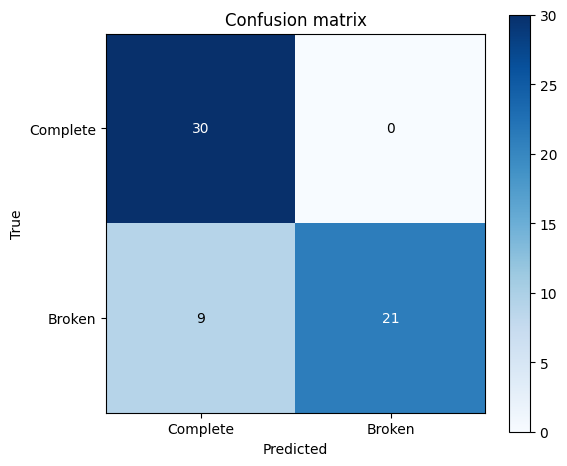

Saved confusion matrix to /storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls/confusion_matrix.png


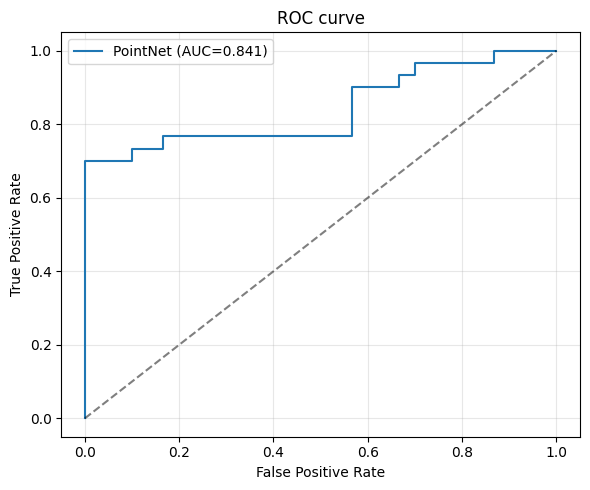

Saved ROC curve to /storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls/roc_curve.png


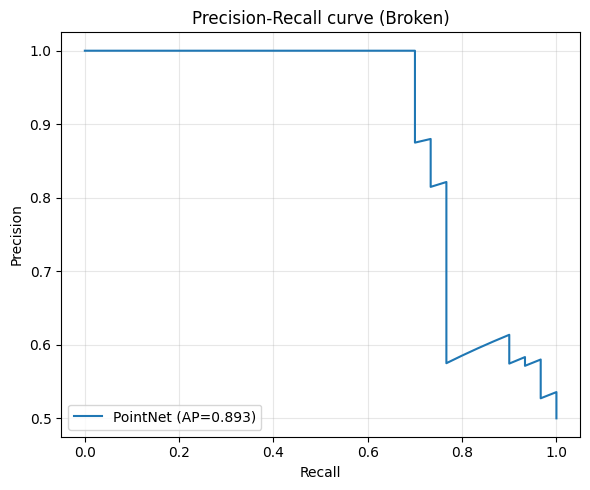

Saved Precision-Recall curve to /storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls/precision_recall_curve_broken.png
Evaluation summary:
  Accuracy        : 0.8500
  Macro F1        : 0.8465
  Broken Precision: 1.0000
  Broken Recall   : 0.7000
  Broken F1       : 0.8235
  Complete Recall : 1.0000
Total errors: 9

Most confident mistakes:
 38 | 07006_b | true=Broken pred=Complete | p_broken=0.0834 | conf=0.9166
 53 | 00021_b | true=Broken pred=Complete | p_broken=0.2293 | conf=0.7707
  5 | 01000_b | true=Broken pred=Complete | p_broken=0.2300 | conf=0.7700
 44 | 00019_b | true=Broken pred=Complete | p_broken=0.2497 | conf=0.7503
 24 | 00015_b | true=Broken pred=Complete | p_broken=0.2568 | conf=0.7432
 52 | 09031_b | true=Broken pred=Complete | p_broken=0.2684 | conf=0.7316
 33 | 00040_b | true=Broken pred=Complete | p_broken=0.2701 | conf=0.7299
  8 | 09018_b | true=Broken pred=Complete | p_broken=0.3136 | conf=0.6864
 46 | 09040_b | true=Broken pred=Complete |

In [11]:
RUN_TRAINING = True
RUN_EVALUATION = True

GRAPH_HANDLES = build_graph(CONFIG)

TRAIN_HISTORY = None
if RUN_TRAINING:
    TRAIN_HISTORY = train_model(CONFIG, DATASET, GRAPH_HANDLES)
    plot_training_curves(TRAIN_HISTORY)

checkpoint_for_eval = None
if TRAIN_HISTORY is not None:
    checkpoint_for_eval = TRAIN_HISTORY['best_checkpoint']
else:
    candidate = str(Path(CONFIG['log_dir']) / 'best_model.ckpt')
    if Path(candidate + '.index').exists():
        checkpoint_for_eval = candidate

if RUN_EVALUATION and checkpoint_for_eval is not None:
    EVAL_RESULT = evaluate_checkpoint(
        CONFIG,
        DATASET,
        GRAPH_HANDLES,
        checkpoint_for_eval,
        limit=CONFIG.get('eval_limit'),
    )
    print(EVAL_RESULT['report'])
    EVAL_PLOT_PATHS = plot_confusion_and_roc(
        EVAL_RESULT,
        output_dir='/storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls',
    )
    summarize_errors(EVAL_RESULT, object_ids=EVAL_RESULT.get('object_ids'), top_k=15)
else:
    EVAL_RESULT = None
    EVAL_PLOT_PATHS = None
    print('Evaluation skipped (no checkpoint available).')


## 10. Random Test-Set Visual Inference

This section now runs **random test-set inference**.

Workflow:
1. Build the aligned test object IDs for the currently loaded dataset subset.
2. Randomly choose `NUM_RANDOM_TEST_SAMPLES` indices from that test set.
3. Run `run_visual_inference(...)` for each sampled test index.
4. Print a compact summary with predicted vs true labels and broken probability.

Set `SHOW_RANDOM_TEST_FIGURES=True` in the final cell if you want a 3D comparison figure for each sampled test object.

In [12]:
import trimesh


def normalize_point_cloud_np(points):
    pts = np.asarray(points, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] != 3 or len(pts) == 0:
        raise ValueError(f'Expected [N, 3] non-empty point cloud, got {pts.shape}')
    pts = pts.copy()
    pts -= pts.mean(axis=0, keepdims=True)
    scale = np.max(np.linalg.norm(pts, axis=1))
    if scale > 0:
        pts /= scale
    return pts


def prepare_inference_batch(point_cloud_np, num_point, seed=0):
    pts = np.asarray(point_cloud_np, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] != 3 or len(pts) == 0:
        raise ValueError(f'Expected [N, 3] non-empty point cloud, got {pts.shape}')

    target_points = int(num_point)
    rng = np.random.default_rng(seed)

    if len(pts) >= target_points:
        idx = rng.choice(len(pts), size=target_points, replace=False)
        pts_processed = pts[idx].copy()
    else:
        extra_idx = rng.choice(len(pts), size=target_points - len(pts), replace=True)
        pts_processed = np.concatenate([pts, pts[extra_idx]], axis=0)

    pts_processed = normalize_point_cloud_np(pts_processed)
    batch = pts_processed[np.newaxis, ...]

    return batch.astype(np.float32), pts_processed.astype(np.float32)


def validate_reconstructed_split(dataset, train_idx, test_idx, labels):
    train_full_indices = np.asarray(
        dataset.get('train_full_indices', np.arange(len(dataset['train_label']))),
        dtype=np.int32,
    )
    test_full_indices = np.asarray(
        dataset.get('test_full_indices', np.arange(len(dataset['test_label']))),
        dtype=np.int32,
    )

    if train_full_indices.size and train_full_indices.max() >= len(train_idx):
        raise ValueError('train_full_indices are out of bounds for reconstructed split.')
    if test_full_indices.size and test_full_indices.max() >= len(test_idx):
        raise ValueError('test_full_indices are out of bounds for reconstructed split.')

    expected_train_labels = labels[train_idx][train_full_indices]
    expected_test_labels = labels[test_idx][test_full_indices]

    if not np.array_equal(expected_train_labels, dataset['train_label']):
        raise ValueError('Reconstructed train split does not match loaded train labels.')
    if not np.array_equal(expected_test_labels, dataset['test_label']):
        raise ValueError('Reconstructed test split does not match loaded test labels.')


def resolve_mesh_path(object_id, data_root=None):
    data_root = Path(data_root or PROJECT_ROOT / 'data' / 'Fantastic_Breaks_v1')
    if not data_root.exists():
        raise FileNotFoundError(f'Could not locate Fantastic_Breaks_v1 at {data_root}')

    base_id, suffix = object_id.rsplit('_', 1)
    mesh_name = 'model_c.ply' if suffix == 'c' else 'model_b_0.ply'
    for category_dir in sorted(data_root.iterdir()):
        candidate = category_dir / base_id / mesh_name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Could not find mesh for object_id={object_id}')


def sample_mesh_for_visualization(mesh, max_points=25000, seed=0):
    if len(mesh.faces) > 0:
        sampled, _ = trimesh.sample.sample_surface(mesh, count=max_points, seed=seed)
        return normalize_point_cloud_np(sampled.astype(np.float32))

    vertices = np.asarray(mesh.vertices, dtype=np.float32)
    if len(vertices) == 0:
        raise ValueError('Mesh has no vertices for visualization')

    if len(vertices) > max_points:
        rng = np.random.default_rng(seed)
        keep = rng.choice(len(vertices), size=max_points, replace=False)
        vertices = vertices[keep]

    return normalize_point_cloud_np(vertices)


def set_axes_equal(ax, points, margin=0.05):
    points = np.asarray(points, dtype=np.float32)
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = (mins + maxs) / 2.0
    radius = max(np.max(maxs - mins) / 2.0, 1e-3)
    radius *= (1.0 + margin)

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')


In [13]:
def plot_inference_comparison(processed_points, mesh_points, object_id, true_label, pred_label, probs, sample_label):
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={'projection': '3d'})

    ax_left.scatter(
        processed_points[:, 0],
        processed_points[:, 1],
        processed_points[:, 2],
        c=processed_points[:, 2],
        cmap='viridis',
        s=3,
        alpha=0.9,
        linewidths=0,
    )
    ax_left.set_title(
        'Processed PointNet input\n'
        f'{sample_label} -> {object_id}\n'
        f'pred={LABEL_NAMES[pred_label]} | p(broken)={probs[1]:.3f}'
    )
    set_axes_equal(ax_left, processed_points)
    ax_left.view_init(elev=20, azim=45)

    ax_right.scatter(
        mesh_points[:, 0],
        mesh_points[:, 1],
        mesh_points[:, 2],
        c=mesh_points[:, 2],
        cmap='plasma',
        s=1.5,
        alpha=0.7,
        linewidths=0,
    )
    ax_right.set_title(
        'Matched mesh surface\n'
        f'object_id={object_id} | true={LABEL_NAMES[true_label]}'
    )
    set_axes_equal(ax_right, mesh_points)
    ax_right.view_init(elev=20, azim=45)

    fig.suptitle('PointNet inference vs. mesh reference', y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


def resolve_inference_input(dataset, cfg, test_object_ids, test_sample_pos=0, input_object_id=None):
    if input_object_id is not None:
        matches = np.where(test_object_ids == input_object_id)[0]
        if len(matches) > 0:
            sample_pos = int(matches[0])
            object_id = str(test_object_ids[sample_pos])
            true_label = int(dataset['test_label'][sample_pos])

            return {
                'object_id': object_id,
                'true_label': true_label,
                'raw_cloud': dataset['test_data'][sample_pos],
                'test_sample_pos': sample_pos,
                'source_desc': f"{Path(cfg['data_dir']) / 'test_data.h5'} [sample {sample_pos}]",
                'mesh_path': None,
                'mesh': None,
            }

        mesh_path = resolve_mesh_path(input_object_id)
        mesh = trimesh.load(mesh_path, force='mesh')
        sampled_points, _ = trimesh.sample.sample_surface(
            mesh,
            cfg['num_point'],
            seed=cfg['classification_split_seed'],
        )
        true_label = 0 if input_object_id.endswith('_c') else 1
        return {
            'object_id': input_object_id,
            'true_label': true_label,
            'raw_cloud': sampled_points.astype(np.float32),
            'test_sample_pos': None,
            'source_desc': f'mesh sampling ({mesh_path})',
            'mesh_path': mesh_path,
            'mesh': mesh,
        }

    sample_pos = int(test_sample_pos)
    if sample_pos < 0 or sample_pos >= len(dataset['test_data']):
        raise IndexError(
            f'test_sample_pos={sample_pos} out of range for {len(dataset["test_data"])} test samples.'
        )

    object_id = str(test_object_ids[sample_pos])
    true_label = int(dataset['test_label'][sample_pos])

    return {
        'object_id': object_id,
        'true_label': true_label,
        'raw_cloud': dataset['test_data'][sample_pos],
        'test_sample_pos': sample_pos,
        'source_desc': f"{Path(cfg['data_dir']) / 'test_data.h5'} [sample {sample_pos}]",
        'mesh_path': None,
        'mesh': None,
    }

In [14]:
def run_visual_inference(
    handles,
    dataset,
    cfg,
    test_sample_pos=0,
    input_object_id=None,
    checkpoint_path=None,
    show_plot=True,
):
    test_object_ids = np.asarray(dataset.get('test_ids', []), dtype=object)
    if len(test_object_ids) != len(dataset['test_data']):
        object_ids = load_object_ids(Path(cfg['data_dir']) / 'object_ids.txt')
        train_idx, test_idx, labels = reconstruct_classification_split(
            object_ids,
            test_ratio=cfg['classification_test_ratio'],
            seed=cfg['classification_split_seed'],
        )
        validate_reconstructed_split(dataset, train_idx, test_idx, labels)

        full_test_object_ids = np.asarray(object_ids, dtype=object)[test_idx]
        test_full_indices = np.asarray(
            dataset.get('test_full_indices', np.arange(len(dataset['test_label']))),
            dtype=np.int32,
        )
        test_object_ids = full_test_object_ids[test_full_indices]

    resolved = resolve_inference_input(
        dataset,
        cfg,
        test_object_ids,
        test_sample_pos=test_sample_pos,
        input_object_id=input_object_id,
    )

    batch_input, processed_points = prepare_inference_batch(
        resolved['raw_cloud'],
        num_point=cfg['num_point'],
        seed=cfg['seed'],
    )

    checkpoint_prefix = str(checkpoint_path or (Path(cfg['log_dir']) / 'best_model.ckpt'))
    if not Path(checkpoint_prefix + '.index').exists():
        raise FileNotFoundError(f'Checkpoint not found: {checkpoint_prefix}')

    session_config = create_session_config()
    with tf1.Session(graph=handles['graph'], config=session_config) as sess:
        handles['saver'].restore(sess, checkpoint_prefix)
        logits = sess.run(
            handles['pred'],
            feed_dict={
                handles['pointclouds_pl']: batch_input,
                handles['labels_pl']: np.zeros(batch_input.shape[0], dtype=np.int32),
                handles['is_training_pl']: False,
            },
        )[0]

    probs = softmax_np(logits[np.newaxis, :])[0]
    pred_label = int(np.argmax(probs))

    mesh = resolved['mesh']
    mesh_path = resolved['mesh_path']
    if mesh is None:
        mesh_path = resolve_mesh_path(resolved['object_id'])
        mesh = trimesh.load(mesh_path, force='mesh')

    mesh_points = sample_mesh_for_visualization(
        mesh,
        max_points=cfg['inference_plot_limit'],
        seed=cfg['classification_split_seed'],
    )

    sample_label = (
        f"test sample {resolved['test_sample_pos']}"
        if resolved['test_sample_pos'] is not None
        else 'manual mesh input'
    )

    print(f"Inference source: {resolved['source_desc']}")
    print(f"Matched object_id: {resolved['object_id']}")
    print(f"Mesh path: {mesh_path}")
    print(
        f"Prediction: {LABEL_NAMES[pred_label]} | probs={np.round(probs, 4)} | "
        f"true={LABEL_NAMES[resolved['true_label']]}"
    )

    fig = plot_inference_comparison(
        processed_points,
        mesh_points,
        resolved['object_id'],
        resolved['true_label'],
        pred_label,
        probs,
        sample_label,
    )
    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    return {
        'object_id': resolved['object_id'],
        'test_sample_pos': resolved['test_sample_pos'],
        'true_label': resolved['true_label'],
        'pred_label': pred_label,
        'probs': probs,
        'mesh_path': Path(mesh_path),
        'figure': fig,
    }


def run_random_test_inference(
    handles,
    dataset,
    cfg,
    num_samples=5,
    seed=None,
    checkpoint_path=None,
    show_plots=False,
):
    total_test = len(dataset['test_data'])
    if total_test == 0:
        raise ValueError('Loaded dataset has no test samples.')

    sample_count = max(1, min(int(num_samples), total_test))
    rng = np.random.default_rng(cfg['seed'] if seed is None else seed)
    sampled_indices = np.sort(rng.choice(total_test, size=sample_count, replace=False))

    print(f"Randomly selected test sample indices: {sampled_indices.tolist()}")
    results = []
    for test_sample_pos in sampled_indices:
        print(f"\n--- Running inference for test sample {int(test_sample_pos)} ---")
        result = run_visual_inference(
            handles,
            dataset,
            cfg,
            test_sample_pos=int(test_sample_pos),
            checkpoint_path=checkpoint_path,
            show_plot=show_plots,
        )
        results.append(result)

    print('\nRandom test inference summary')
    for result in results:
        match = 'MATCH' if result['pred_label'] == result['true_label'] else 'MISMATCH'
        print(
            f"  idx={result['test_sample_pos']:3d} "
            f"object_id={result['object_id']:>8s} "
            f"pred={LABEL_NAMES[result['pred_label']]:>8s} "
            f"true={LABEL_NAMES[result['true_label']]:>8s} "
            f"p(broken)={result['probs'][1]:.3f} "
            f"{match}"
        )

    return results


In [15]:
VALID_TEST_OBJECT_IDS = np.asarray(DATASET.get('test_ids', []), dtype=object)
if len(VALID_TEST_OBJECT_IDS) != len(DATASET['test_label']):
    OBJECT_IDS = load_object_ids(Path(CONFIG['data_dir']) / 'object_ids.txt')
    _, TEST_IDX, _ = reconstruct_classification_split(
        OBJECT_IDS,
        test_ratio=CONFIG['classification_test_ratio'],
        seed=CONFIG['classification_split_seed'],
    )
    FULL_TEST_OBJECT_IDS = np.asarray(OBJECT_IDS, dtype=object)[TEST_IDX]
    TEST_FULL_INDICES = np.asarray(
        DATASET.get('test_full_indices', np.arange(len(DATASET['test_label']))),
        dtype=np.int32,
    )
    VALID_TEST_OBJECT_IDS = FULL_TEST_OBJECT_IDS[TEST_FULL_INDICES]

print(f'Valid test object IDs in current DATASET: {len(VALID_TEST_OBJECT_IDS)} total')
for idx, object_id in enumerate(VALID_TEST_OBJECT_IDS[:12]):
    print(f'  {idx:3d}: {object_id}')
if len(VALID_TEST_OBJECT_IDS) > 12:
    print(f'  ... and {len(VALID_TEST_OBJECT_IDS) - 12} more')


Valid test object IDs in current DATASET: 60 total
    0: 09006_c
    1: 06002_b
    2: 12006_c
    3: 07005_c
    4: 00043_c
    5: 01000_b
    6: 01020_b
    7: 00002_c
    8: 09018_b
    9: 02010_b
   10: 09017_c
   11: 01024_b
  ... and 48 more


Randomly selected test sample indices: [6, 29, 38, 45, 52]

--- Running inference for test sample 6 ---
INFO:tensorflow:Restoring parameters from /storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls/best_model.ckpt


2026-03-25 11:21:22.551805: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18522 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:18:00.0, compute capability: 8.6
2026-03-25 11:21:22.552055: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22278 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2026-03-25 11:21:22.552265: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22278 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6
2026-03-25 11:21:22.552471: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22278 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090

Inference source: /storage/student6/dev/3D-Segmentation-Restoration/data/classification/test_data.h5 [sample 6]
Matched object_id: 01020_b
Mesh path: /storage/student6/dev/3D-Segmentation-Restoration/data/Fantastic_Breaks_v1/01/01020/model_b_0.ply
Prediction: Broken | probs=[0.0125 0.9875] | true=Broken


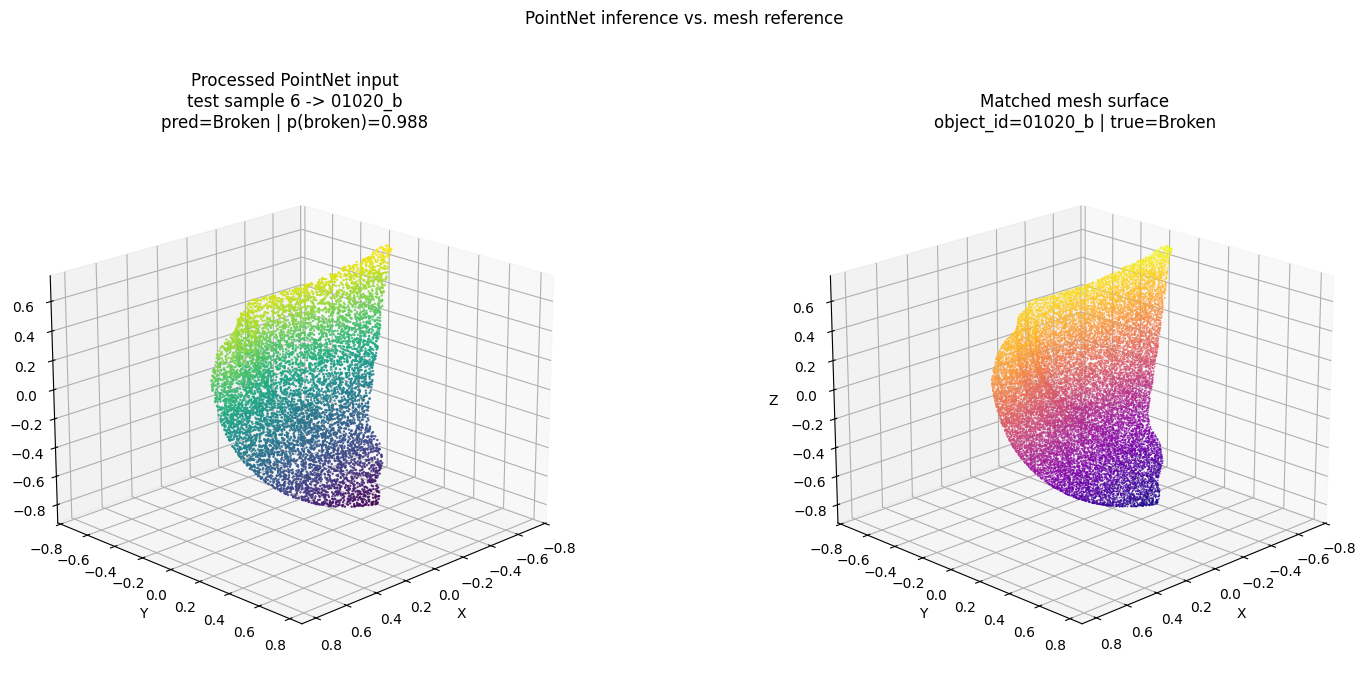


--- Running inference for test sample 29 ---
INFO:tensorflow:Restoring parameters from /storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls/best_model.ckpt


2026-03-25 11:21:26.973546: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18522 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:18:00.0, compute capability: 8.6
2026-03-25 11:21:26.973729: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22278 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2026-03-25 11:21:26.973895: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22278 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6
2026-03-25 11:21:26.974056: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22278 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090

Inference source: /storage/student6/dev/3D-Segmentation-Restoration/data/classification/test_data.h5 [sample 29]
Matched object_id: 02008_c
Mesh path: /storage/student6/dev/3D-Segmentation-Restoration/data/Fantastic_Breaks_v1/02/02008/model_c.ply
Prediction: Complete | probs=[0.9616 0.0384] | true=Complete


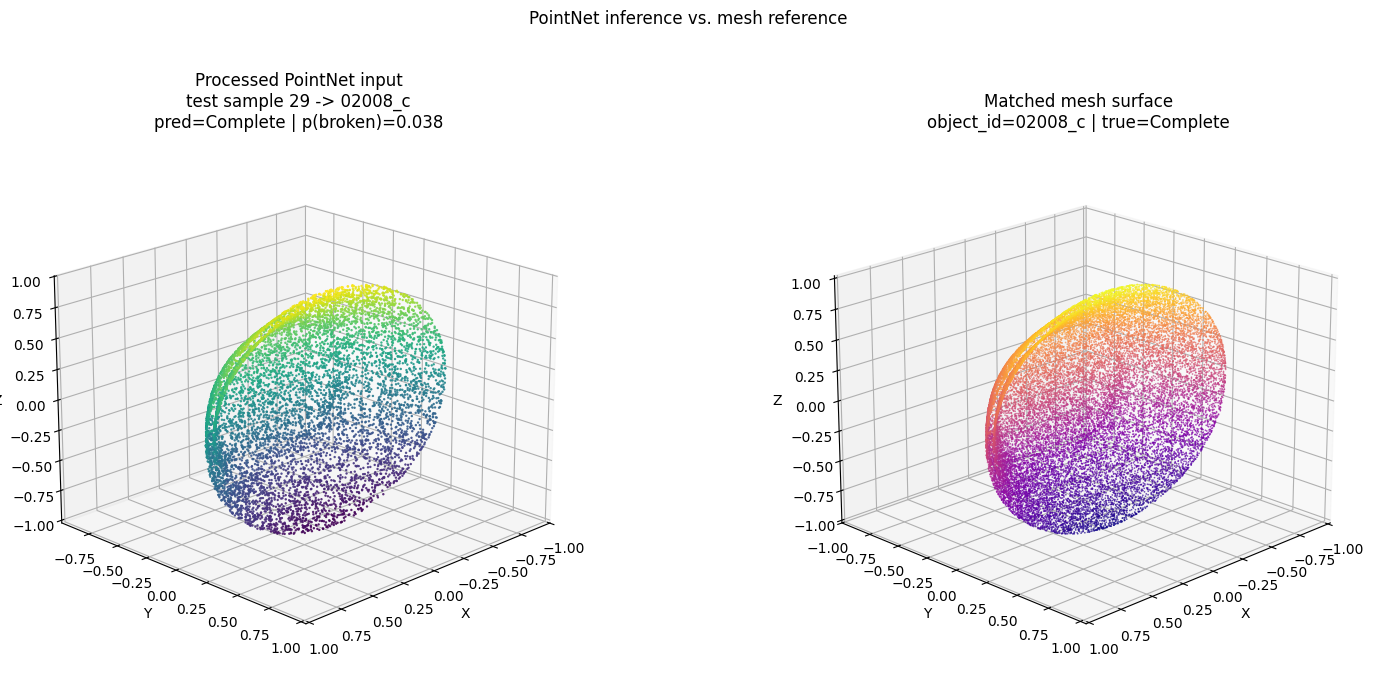


--- Running inference for test sample 38 ---
INFO:tensorflow:Restoring parameters from /storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls/best_model.ckpt


2026-03-25 11:21:31.787187: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18522 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:18:00.0, compute capability: 8.6
2026-03-25 11:21:31.787384: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22278 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2026-03-25 11:21:31.787553: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22278 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6
2026-03-25 11:21:31.787723: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22278 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090

Inference source: /storage/student6/dev/3D-Segmentation-Restoration/data/classification/test_data.h5 [sample 38]
Matched object_id: 07006_b
Mesh path: /storage/student6/dev/3D-Segmentation-Restoration/data/Fantastic_Breaks_v1/07/07006/model_b_0.ply
Prediction: Complete | probs=[0.9166 0.0834] | true=Broken


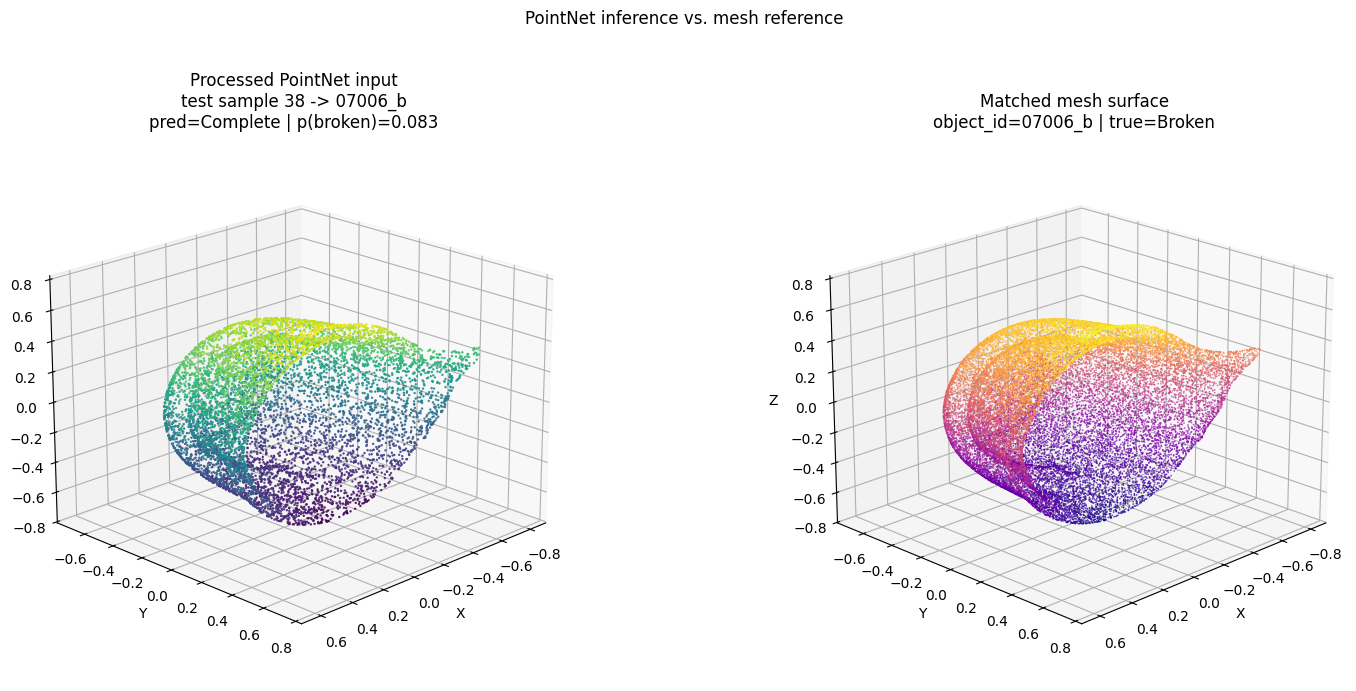


--- Running inference for test sample 45 ---
INFO:tensorflow:Restoring parameters from /storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls/best_model.ckpt


2026-03-25 11:21:37.593072: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18522 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:18:00.0, compute capability: 8.6
2026-03-25 11:21:37.593252: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22278 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2026-03-25 11:21:37.593412: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22278 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6
2026-03-25 11:21:37.593571: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22278 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090

Inference source: /storage/student6/dev/3D-Segmentation-Restoration/data/classification/test_data.h5 [sample 45]
Matched object_id: 09019_c
Mesh path: /storage/student6/dev/3D-Segmentation-Restoration/data/Fantastic_Breaks_v1/09/09019/model_c.ply
Prediction: Complete | probs=[0.7933 0.2067] | true=Complete


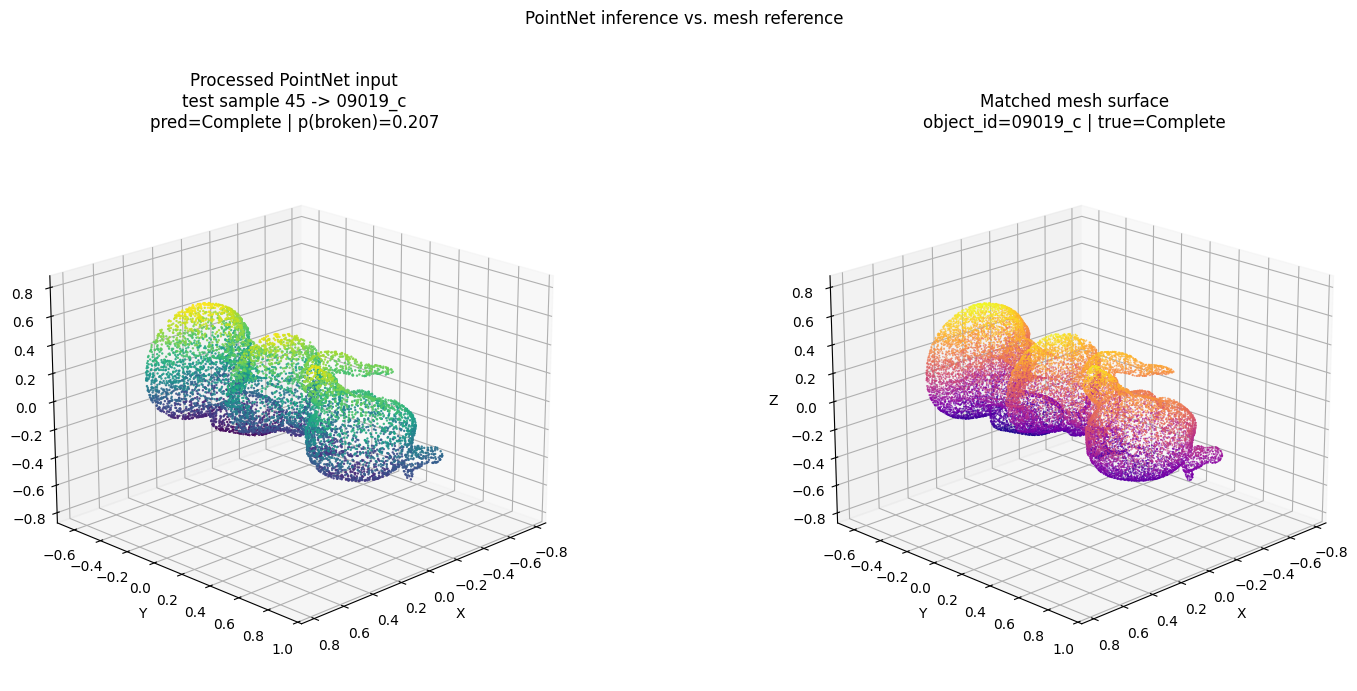


--- Running inference for test sample 52 ---
INFO:tensorflow:Restoring parameters from /storage/student6/dev/3D-Segmentation-Restoration/src/results/pointnet_cls/best_model.ckpt


2026-03-25 11:21:42.405535: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18522 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:18:00.0, compute capability: 8.6
2026-03-25 11:21:42.405732: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22278 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
2026-03-25 11:21:42.405897: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22278 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:86:00.0, compute capability: 8.6
2026-03-25 11:21:42.406057: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22278 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090

Inference source: /storage/student6/dev/3D-Segmentation-Restoration/data/classification/test_data.h5 [sample 52]
Matched object_id: 09031_b
Mesh path: /storage/student6/dev/3D-Segmentation-Restoration/data/Fantastic_Breaks_v1/09/09031/model_b_0.ply
Prediction: Complete | probs=[0.7315 0.2685] | true=Broken


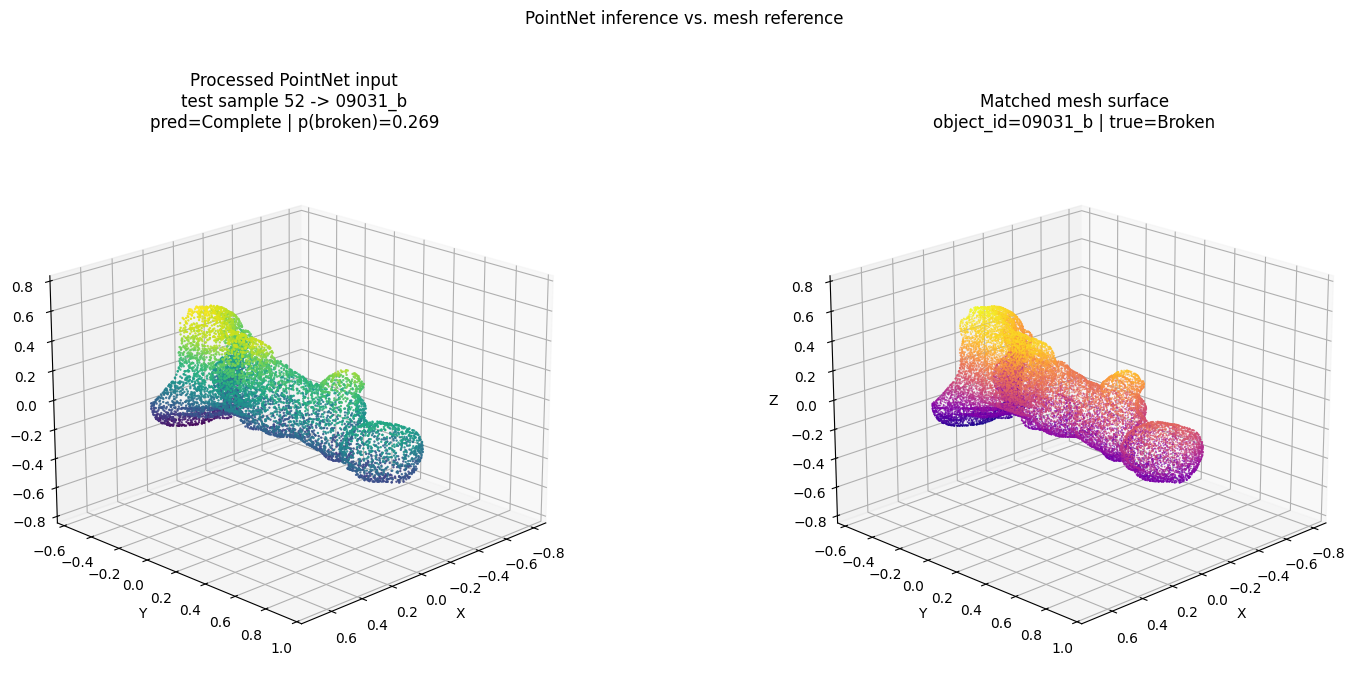


Random test inference summary
  idx=  6 object_id= 01020_b pred=  Broken true=  Broken p(broken)=0.988 MATCH
  idx= 29 object_id= 02008_c pred=Complete true=Complete p(broken)=0.038 MATCH
  idx= 38 object_id= 07006_b pred=Complete true=  Broken p(broken)=0.083 MISMATCH
  idx= 45 object_id= 09019_c pred=Complete true=Complete p(broken)=0.207 MATCH
  idx= 52 object_id= 09031_b pred=Complete true=  Broken p(broken)=0.269 MISMATCH


In [16]:
NUM_RANDOM_TEST_SAMPLES = 5
RANDOM_TEST_SEED = CONFIG['seed'] + 2026
SHOW_RANDOM_TEST_FIGURES = True

checkpoint_for_inference = None
if TRAIN_HISTORY is not None:
    checkpoint_for_inference = TRAIN_HISTORY['best_checkpoint']
else:
    default_checkpoint = str(Path(CONFIG['log_dir']) / 'best_model.ckpt')
    if Path(default_checkpoint + '.index').exists():
        checkpoint_for_inference = default_checkpoint

if checkpoint_for_inference is None:
    print('Skipping random test inference because no checkpoint was found.')
    RANDOM_TEST_INFERENCE_RESULTS = None
else:
    RANDOM_TEST_INFERENCE_RESULTS = run_random_test_inference(
        GRAPH_HANDLES,
        DATASET,
        CONFIG,
        num_samples=NUM_RANDOM_TEST_SAMPLES,
        seed=RANDOM_TEST_SEED,
        checkpoint_path=checkpoint_for_inference,
        show_plots=SHOW_RANDOM_TEST_FIGURES,
    )